# Regime Detection & Dynamic Allocation

**Category:** AI/ML Trading  
**Project ID:** `ml_01_regime_detection`  

Multi-model regime detection (HMM, Markov-switching, clustering) with meta-policy dynamic strategy allocation


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"
print("  [GPU recommended for this project — deep learning / RL]")
# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


  [GPU recommended for this project — deep learning / RL]


            os: Windows
        python: 3.13.2
        device: CPU (torch unavailable: ModuleNotFoundError)
         numpy: 2.3.0
        pandas: 2.3.3
         scipy: 1.17.1
       sklearn: 1.8.0
    matplotlib: 3.10.3


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"num_regimes": 4, "lookback_days": 252}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                num_regimes: 4
              lookback_days: 252


Data shape: (752, 5)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       SPY
count   752.0000
mean    444.5639
std      68.8578
min     341.1821
25%     390.6235
50%     423.9385
75%     500.4846
max     598.7401


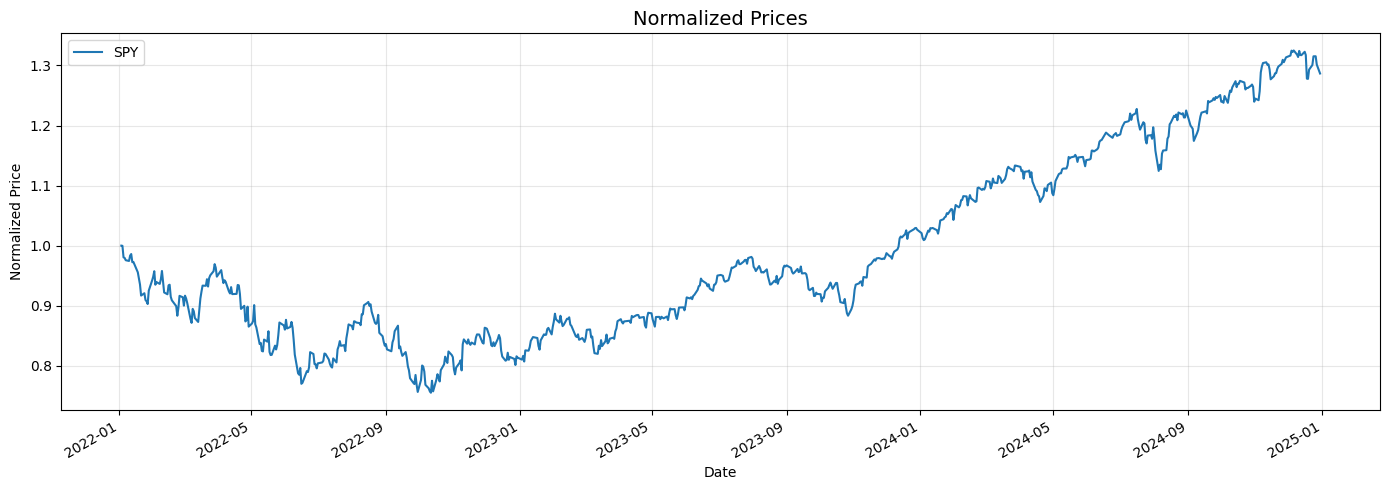

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = 'SPY'
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Feature Engineering

In [4]:
import pandas as pd
import numpy as np

# Feature engineering for ML model
price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
price = price.ffill()
returns = price.pct_change()

features = pd.DataFrame(index=price.index)

# Technical features
for lag in [1, 5, 10, 21, 63]:
    features[f"ret_{lag}d"] = price.pct_change(lag)
    features[f"vol_{lag}d"] = returns.rolling(max(lag, 2)).std()  # std needs >=2 obs

# Moving average features
for window in [10, 20, 50]:
    features[f"ma_ratio_{window}"] = price / price.rolling(window).mean() - 1

# RSI-14
gain = returns.clip(lower=0).rolling(14).mean()
loss = returns.clip(upper=0).abs().rolling(14).mean()
features["rsi_14"] = 100 - 100 / (1 + gain / loss.replace(0, np.nan).fillna(1e-9))

features = features.dropna()
print(f"Features shape: {features.shape}")
print(f"\nFeature correlations with 5d forward return:")
fwd_ret = returns.shift(-5).reindex(features.index)
corrs = features.corrwith(fwd_ret).sort_values(ascending=False)
print(corrs.head(10))


Features shape: (689, 14)

Feature correlations with 5d forward return:
ret_5d         0.020467
rsi_14        -0.000147
vol_1d        -0.006354
ma_ratio_10   -0.009859
ma_ratio_20   -0.010050
vol_10d       -0.010861
ret_10d       -0.016697
vol_21d       -0.017888
vol_63d       -0.020414
ret_21d       -0.023568
dtype: float64


## Regime Classifier Training

In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Target: 5-day forward return direction (up/down regime)
target = (returns.shift(-5) > 0).astype(int).reindex(features.index).dropna()
features_aligned = features.loc[target.index]

split_idx = int(len(features_aligned) * PARAMS.get("train_ratio", 0.7))
embargo   = PARAMS.get("embargo_days", 10)

X_train = features_aligned.iloc[:split_idx - embargo]
y_train = target.iloc[:split_idx - embargo]
X_test  = features_aligned.iloc[split_idx:]
y_test  = target.iloc[split_idx:]

print(f"Train: {len(X_train)}, Test: {len(X_test)}, Embargo: {embargo} days")

model = GradientBoostingClassifier(
    n_estimators=PARAMS.get("n_estimators", 200),
    max_depth=PARAMS.get("max_depth", 4),
    learning_rate=PARAMS.get("learning_rate", 0.05),
    subsample=PARAMS.get("subsample", 0.8),
    random_state=SEED,
)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))
print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(classification_report(y_test, model.predict(X_test)))

importances = (
    pd.Series(model.feature_importances_, index=features.columns)
    .sort_values(ascending=False)
)
print("Top 10 features:")
print(importances.head(10))


Train: 472, Test: 207, Embargo: 10 days



Train accuracy: 1.0000
Test accuracy:  0.5652
              precision    recall  f1-score   support

           0       0.47      0.26      0.34        87
           1       0.59      0.78      0.68       120

    accuracy                           0.57       207
   macro avg       0.53      0.52      0.51       207
weighted avg       0.54      0.57      0.53       207

Top 10 features:
ret_1d     0.110573
vol_1d     0.108098
ret_5d     0.080726
ret_63d    0.080660
vol_21d    0.075278
rsi_14     0.072337
vol_5d     0.070289
ret_21d    0.069464
vol_10d    0.064891
ret_10d    0.062854
dtype: float64


## Backtest

In [6]:
import pandas as pd
import numpy as np

predictions = model.predict_proba(X_test)[:, 1]
signal = pd.Series(predictions, index=X_test.index)
positions = (signal - 0.5).clip(-1, 1)

test_returns = returns.reindex(X_test.index)
strategy_returns_raw = (positions.shift(1) * test_returns).dropna()

equity_curve     = (1 + strategy_returns_raw).cumprod()
benchmark_equity = (1 + test_returns.loc[equity_curve.index]).cumprod()

print(f"Backtest: {equity_curve.index[0].date()} to {equity_curve.index[-1].date()}")
print(f"Strategy final: {equity_curve.iloc[-1]:.4f}  |  Benchmark: {benchmark_equity.iloc[-1]:.4f}")


Backtest: 2024-03-07 to 2024-12-30
Strategy final: 1.0177  |  Benchmark: 1.1687


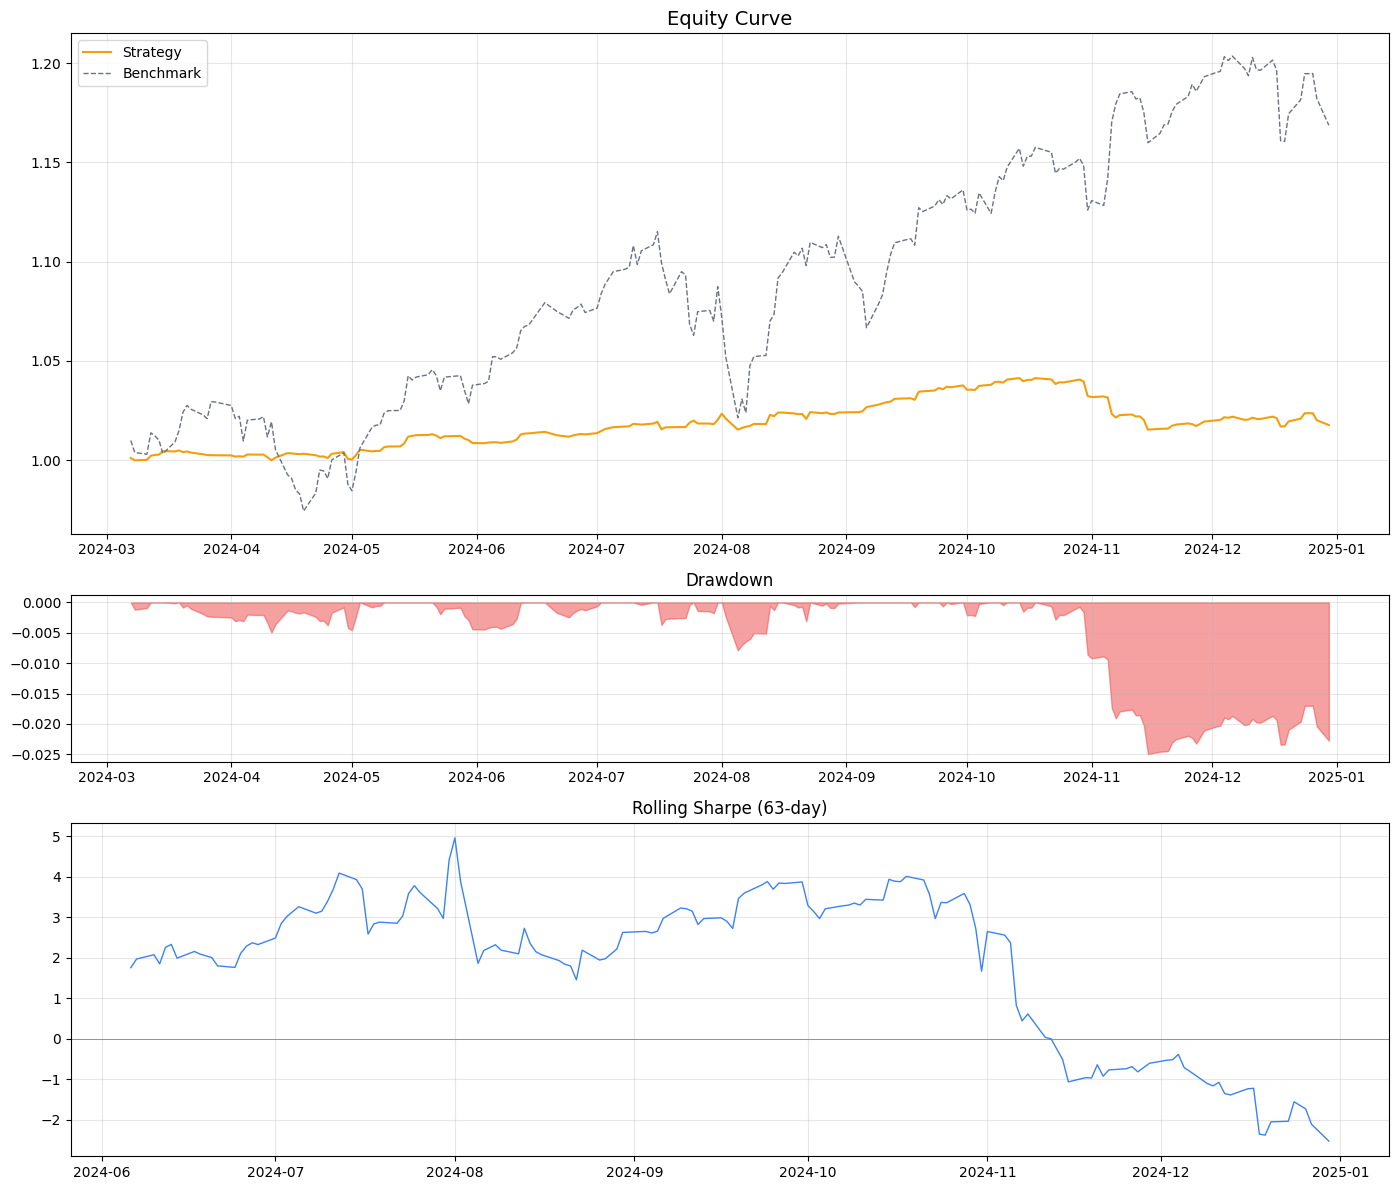

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +1.66%
                       cagr: +2.04%
             annualized_vol: +2.44%
               sharpe_ratio: 0.8391
              sortino_ratio: 0.8571
               calmar_ratio: 0.8174
               max_drawdown: -2.49%
                   win_rate: +60.49%
              profit_factor: 1.1800
               total_trades: 205


In [9]:
from scipy.stats import spearmanr
import pandas as pd

aligned = pd.DataFrame({
    "prediction": signal,
    "actual": returns.shift(-5).reindex(signal.index),
}).dropna()

ic, _ = spearmanr(aligned["prediction"], aligned["actual"])
dir_acc = ((aligned["prediction"] > 0.5) == (aligned["actual"] > 0)).mean()

print("=" * 50)
print("REGIME DETECTION METRICS")
print("=" * 50)
print(f"  {'Information Coefficient':>25}: {ic:.4f}")
print(f"  {'Directional Accuracy':>25}: {dir_acc:.4f}")
print(f"  {'Test Accuracy (GBM)':>25}: {test_acc:.4f}")


REGIME DETECTION METRICS
    Information Coefficient: 0.0601
       Directional Accuracy: 0.5792
        Test Accuracy (GBM): 0.5652


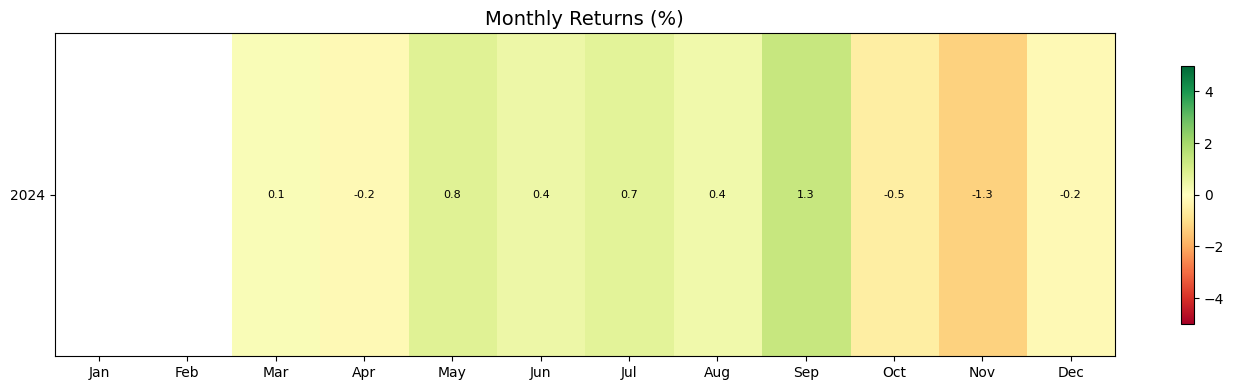

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monthly returns heatmap — requires DatetimeIndex; skipped for synthetic/HFT data
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
except Exception:
    print("Monthly heatmap skipped: equity curve does not have a DatetimeIndex (synthetic data).")
    monthly = None

if monthly is not None:
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="return")
    pivot = pivot.reindex(columns=range(1, 13))  # ensure all 12 months present
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Monthly Returns (%)", fontsize=14)

    # Text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < 0.03 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


In [11]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "ml_01_regime_detection",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Regime Detection & Dynamic Allocation

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
